# Conditions (Quantum and Classical)

## Overview
This notebook demonstrates various methods for performing conditional operations in the Workbench.

### Runtime Requirements
To run these examples, please ensure that **psiqworkbench** and **numpy** are installed. No additional libraries are required.

### Different kinds of conditions
In many scenarios, you may not want every gate to be executed unconditionally. Workbench offers multiple ways to determine when gates are applied:
- **Branching** enables you to decide when to issue QPU operations, simply by using Python’s `if` statements.
- **Classical feedforward** makes it possible to conditionally apply QPU operations based on measurement outcomes.
- **Jump forward** allows you to skip over certain QPU operations, depending on measurement outcomes.
- **Quantum conditions (or controls)** let you apply QPU operations to specific parts of the quantum state while leaving other parts unaffected.

---

## Case 1: Four types of conditions
In the following example, we employ all four types of conditions. Our goal is to implement the following assertion: _“If the lowest qubit in `a` is 1, apply an X gate to `b`. Otherwise, apply a Z gate to `b`.”_

We will examine each case individually.

---
### Example 1: if/else Branching
```python
    aa = a[0].read()                     # Measure a and WAIT for the result
    if aa:
        b.x()
    else:
        b.z()

    qc.nop(repeat=4)
    qc.draw()
```
This approach is straightforwardly uses a Python `if` statement. When `read()` is called, the program **waits** for the measurement outcome before deciding which branch to execute. Note that one of the operations does not appear in the diagram, as that block of Python code was never executed.

- **Advantages:**
  - The `if` condition can perform any arbitrary logic. You can check external services, databases, or any other resource.
- **Disadvantages:**
  - The instruction pipeline pauses while waiting for the measurement, slowing down the process—particularly on a real QPU, where network delays may apply.
  - The circuit diagram does not show that any logic occurred, or in what order the gates were executed.
  - If you save the instructions and run them later (as compilers typically do), the behavior will be incorrect because the logic was determined by Python.

---
### Case 2: Classical feedforward
```python
    aa = a[0].read_async()               # Measure a but DON'T WAIT for the result
    with aa:                            # Apply these ops if a==1
        b.x()
    with aa == 0:                       # Apply these ops if a==0
        b.z()

    qc.nop(repeat=4)
    qc.draw()
```

Here, the program **does not wait** for the measurement result. Instead, it attaches flags to the operations, indicating they should only be executed if the measured classical condition is satisfied.

- **Advantages:**
  - This method is much more efficient.
  - The diagram shows that certain operations are conditionally applied, even if it does not clarify the exact logic.
  - Saving and re-running the instructions preserves correctness.
- **Disadvantages:**
  - This approach is less flexible; only certain operations on deferred `read_async()` results are allowed.

---
### Case 3: Jump forward
```python
    aa = a[0].read_async()         # Measure a but DON'T WAIT for the result    
    with aa == 0:                  # Jump over these if a==0
        j1 = qc.jump_fwd()
    b.x()
    qc.jump_fwd_target(j1)

    with aa == 1:                       # Jump over these if a==1
        j2 = qc.jump_fwd()
    b.z()
    qc.jump_fwd_target(j2)

    qc.nop(repeat=4)
    qc.draw()
```

As with classical feedforward, the program **does not wait** for the measurement. Instead, it relies on jump instructions, which the QPU either follows or bypasses based on the measurement outcome.

- **Advantages:**
  - For more extensive conditional code, jump instructions can be simpler and more efficient than applying conditions to every gate.
  - The diagram indicates that jumps are conditional, even if the specific logic is not fully revealed.
  - If you save and re-run the instructions, the correct behavior is maintained.
- **Disadvantages:**
  - Less flexibility, only specific operations on deferred `read_async()` results are supported.

---
### Case 4: Quantum control
```python
    b.x(a[0])                            # Normal CNOT
    b.z(~a[0])                           # Normal CZ with inverted control

    qc.nop(repeat=4)
    qc.draw()
```

This approach uses standard quantum controlled operations, which always execute, but only affect the portion of the quantum state in which the control qubit(s) are set. The `~` operator inverts the control logic.

- **Advantages:**
  - Enables quantum superposition and entanglement-based logic.
  - The diagram explicitly reflects all activity.
  - Saving and re-running the instructions retains correctness.
- **Disadvantages:**
  - Certain conditions may be complex to implement purely as quantum controls. Later examples will illustrate potential pitfalls.
  - Adds aditional quantum operations to the program

---

Each example is implemented int the code sample below.

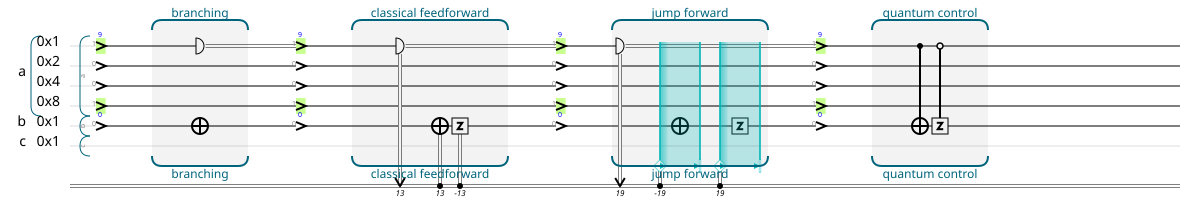

In [1]:
from psiqworkbench import QPU, Qubits


def run():
    # Note we put the >>buffer>> first so we can inspect jump instructions before >>qpu>> processes them.
    qc = QPU(filters=['>>buffer>>', '>>qpu>>'])  # Create a QPU
    qc.reset(6)                          # Initialize it with some qubits
    qc._enable_jumps = False             # Disable jumps so we can see them in the diagram
    a = Qubits(4, 'a', qc)               # Allocate a register to test on
    b = Qubits(1, 'b', qc)               # Allocate a register to test on
    c = Qubits(1, 'c', qc)               # Allocate a register to test on
    
    a.write(9)                           # Set some initial values
    b.write(0)                           # Set some initial values

    for i in range(2):                   # Just space things out a bit to look nice
        qc.nop()

    qc.label('branching')

    #########################
    aa = a[0].read()                     # Measure a and WAIT for the result
    if aa:
        b.x()
    else:
        b.z()
    #########################

    qc.label('')
    for i in range(2):                   # Just space things out a bit to look nice
        qc.nop()
    a.write(9)                           # Set some initial values
    b.write(0)                           # Set some initial values
    for i in range(2):                   # Just space things out a bit to look nice
        qc.nop()
        

    qc.label('classical feedforward')

    #########################
    aa = a[0].read_async()               # Measure a but DON'T WAIT for the result
    qc.nop()
    with aa:                            # Tell the QPU to only apply these if a==1
        b.x()
    with aa == 0:                       # Tell the QPU to only apply these if a==0
        b.z()
    #########################

    qc.label('')
    for i in range(2):                   # Just space things out a bit to look nice
        qc.nop()
    a.write(9)                           # Set some initial values
    b.write(0)                           # Set some initial values
    for i in range(2):                   # Just space things out a bit to look nice
        qc.nop()
        
        
    qc.label('jump forward')

    #########################
    aa = a[0].read_async()               # Measure a but DON'T WAIT for the result
    qc.nop()
    with aa == 0:                            # Tell the QPU to only apply these if a==1
        j1 = qc.jump_fwd()
    b.x()
    qc.jump_fwd_target(j1)

    with aa:                       # Tell the QPU to only apply these if a==0
        j2 = qc.jump_fwd()
    b.z()
    qc.jump_fwd_target(j2)
    #########################

    
    qc.label('')
    for i in range(2):                   # Just space things out a bit to look nice
        qc.nop()
    a.write(9)                           # Set some initial values
    b.write(0)                           # Set some initial values
    for i in range(2):                   # Just space things out a bit to look nice
        qc.nop()
        
        

    qc.label('quantum control')

    #########################
    b.x(a[0])                            # This is a normal CNOT
    b.z(~a[0])                           # This is a normal CZ with the control flipped
    #########################

    qc.label('')
    for i in range(10):                  # Just space things out a bit to look nice
        qc.nop()
        
        


    qc.draw()                            # Draw the whole circuit
    
run()

---

## Example 2: Advanced Use
Now, we demonstrate a scenario with slightly more complex conditions. Suppose we want to do the following: _“If `a == 5`, apply an X gate to `b`. If `a < 13`, apply a Z gate to `b`.”_

Once again, we will examine each case separately.

---
### Case 1: if/else Branching
```python
    aa = a.read()
    if aa == 5:
        b.x()
    if aa < 13:
        b.z()
    qc.nop(repeat=4)
    qc.draw()
```
This code still uses a Python `if` statement. Calling `read()` forces the program to wait for the result before deciding which operations to execute. Note that any operation not triggered by the condition will be absent from the diagram.

- **Advantages:**
  - The logic can be completely arbitrary, including external queries or additional computations.
- **Disadvantages:**
  - The pipeline pauses for the measurement, incurring potential overhead.
  - The diagram does not show the branching logic.
  - Saving and re-running the instructions does not replicate the same conditional logic.

---
### Case 2: Classical feedforward
```python
    aa = a.read_async()                 # Measure a but DON'T WAIT for the result
    with aa == 5:                       # Apply if a == 5
        b.x()
    with aa < 13:                       # Apply if a < 13
        b.z()
    qc.nop(repeat=4)
    qc.draw()
```
As before, we do not wait on the measurement result. Instead, conditional flags are attached to each operation.

- **Advantages:**
  - Efficiency is much higher than branching.
  - The diagram indicates conditionally applied operations.
  - Correctness is preserved when saving and re-running instructions.
- **Disadvantages:**
  - Only certain operations on deferred measurement results are possible.

---
### Case 3: Jump forward
```python
    aa = a.read_async()                 # Measure a but DON'T WAIT for the result
    with aa != 5:                       # Jump over these if a != 5
        j1 = qc.jump_fwd()
    b.x()
    qc.jump_fwd_target(j1)

    with aa >= 13:                      # Jump over these if a >= 13
        j2 = qc.jump_fwd()
    b.z()
    qc.jump_fwd_target(j2)

    qc.nop(repeat=4)
    qc.draw()
```

This approach also uses deferred measurement results, but implements the logic via jump instructions.

- **Advantages:**
  - Efficient for complex blocks of conditional gates.
  - The diagram reflects that the QPU may skip certain steps.
  - Saving and re-running instructions works as intended.
- **Disadvantages:**
  - Constrained by the same limitations as classical feedforward.

---
### Case 4: Quantum control
```python
    b.x(a == 5)
    with a < 13 as cond:
        b.z(cond)

    qc.nop(repeat=4)
    qc.draw()
```

This code, while visually simple, can appear intimidating in the diagram. Because comparing `a < 13` involves multiple qubits, Workbench must perform quantum logic to evaluate the condition in superposition. The system must also allocate additional qubits to store this computation and uncompute it afterward.

- **Advantages:**
  - Provides advanced quantum capabilities.
  - The diagram accurately illustrates all quantum logic performed.
  - Saving and re-running instructions remains correct.
- **Disadvantages:**
  - Operations like `<` can require substantial overhead, both in logic and qubit usage.

---

Each case is implemented in the code below.

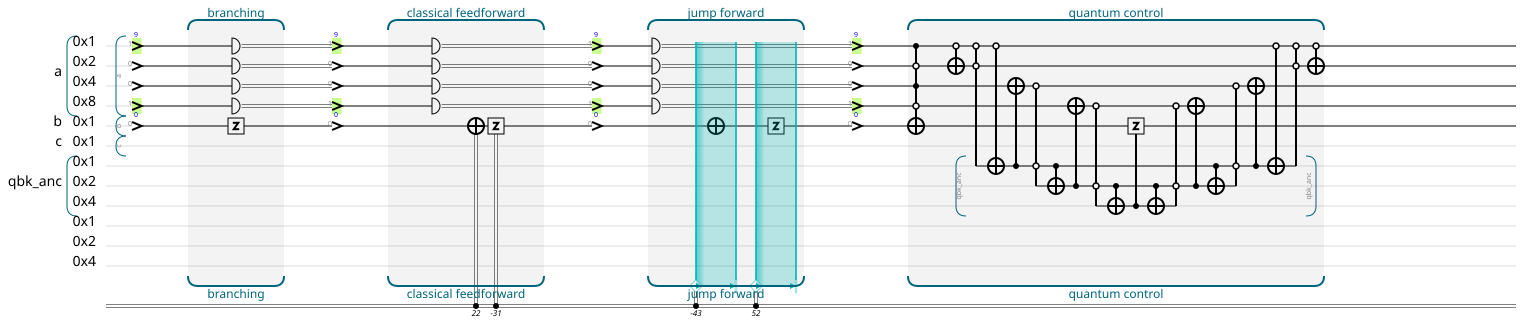

In [2]:
from psiqworkbench import QPU, Qubits


def run():
    # Note we put the >>buffer>> first so we can inspect jump instructions before >>qpu>> processes them.
    qc = QPU(filters=['>>buffer>>', '>>qpu>>'])  # Create a QPU
    qc.reset(12)                         # Initialize it with some qubits
    a = Qubits(4, 'a', qc)               # Allocate a register to test on
    b = Qubits(1, 'b', qc)               # Allocate a register to test on
    c = Qubits(1, 'c', qc)               # Allocate a register to test on
    
    a.write(9)                           # Set some initial values
    b.write(0)                           # Set some initial values

    for i in range(2):                   # Just space things out a bit to look nice
        qc.nop()

    qc.label('branching')

    #########################
    aa = a.read()                        # Measure a and WAIT for the result
    if aa == 5:
        b.x()
    if aa < 13:
        b.z()
    #########################

    qc.label('')
    for i in range(2):                   # Just space things out a bit to look nice
        qc.nop()
    a.write(9)                           # Set some initial values
    b.write(0)                           # Set some initial values
    for i in range(2):                   # Just space things out a bit to look nice
        qc.nop()
        
        

    qc.label('classical feedforward')

    #########################
    aa = a.read_async()                 # Measure a but DON'T WAIT for the result
    qc.nop()
    with aa == 5:                       # Tell the QPU to only apply these if a == 5
        b.x()
    with aa < 13:                       # Tell the QPU to only apply these if a < 13
        b.z()
    #########################

    qc.label('')
    for i in range(2):                   # Just space things out a bit to look nice
        qc.nop()
    a.write(9)                           # Set some initial values
    b.write(0)                           # Set some initial values
    for i in range(2):                   # Just space things out a bit to look nice
        qc.nop()
        
        

    qc.label('jump forward')

    #########################
    aa = a.read_async()                 # Measure a but DON'T WAIT for the result
    qc.nop()
    with aa != 5:                       # Tell the QPU to jump over these if a != 5
        j1 = qc.jump_fwd()
    b.x()
    qc.jump_fwd_target(j1)
    
    with aa >= 13:                      # Tell the QPU to jump over these if a >= 13
        j2 = qc.jump_fwd()
    b.z()
    qc.jump_fwd_target(j2)
    #########################

    qc.label('')
    for i in range(2):                   # Just space things out a bit to look nice
        qc.nop()
    a.write(9)                           # Set some initial values
    b.write(0)                           # Set some initial values
    for i in range(2):                   # Just space things out a bit to look nice
        qc.nop()
        
        

    qc.label('quantum control')

    #########################
    b.x(a == 5)
    qc.nop()
    with a < 13 as cond:
        b.z(cond)
    #########################

    qc.label('')
    for i in range(10):                   # Just space things out a bit to look nice
        qc.nop()
        
        


    qc.draw()                            # Draw the whole circuit
    
run()

---

## Example 3: Classical feedforward zoo
What kinds of things can you do with feedforward, and what do they look like?

Here's a pretty full list of things.

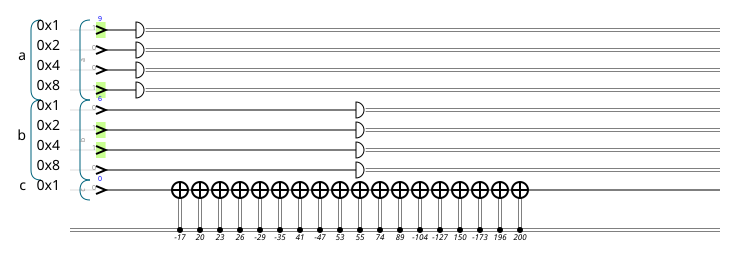

In [3]:
from psiqworkbench import QPU, Qubits


def run():
    qc = QPU()                           # Create a QPU
    qc.reset(9)                          # Initialize it with some qubits
    a = Qubits(4, 'a', qc)               # Allocate a register to test on
    b = Qubits(4, 'b', qc)               # Allocate a register to test on
    c = Qubits(1, 'c', qc)               # Allocate a register to test on
    
    a.write(9)                           # Set some initial values
    b.write(6)                           # Set some initial values
    c.write(0)                           # Set some initial values

    qc.nop()


    aa = a.read_async()                 # Measure a but DON'T WAIT for the result
    qc.nop()

    with aa:                            # Tell the QPU to only apply these if a is non-zero
        c.x()
    with aa == 0:                       # Tell the QPU to only apply these if a is non-zero
        c.x()
    with aa == 5:                       # Tell the QPU to only apply these if a == 5
        c.x()
    with ~aa == 5:                      # Tell the QPU to only apply these if ~a == 5
        c.x()
    with aa != 5:                       # Tell the QPU to only apply these if a != 5
        c.x()
    with aa < 5:                        # Tell the QPU to only apply these if a < 5
        c.x()
    with aa <= 5:                       # Tell the QPU to only apply these if a <= 5
        c.x()
    with aa > 5:                        # Tell the QPU to only apply these if a > 5
        c.x()
    with aa >= 5:                       # Tell the QPU to only apply these if a >= 5
        c.x()
    with (aa & 7) == 5:                 # Tell the QPU to only apply these if (a & 7) == 5
        c.x()

    bb = b.read_async()                 # Measure a but DON'T WAIT for the result
    with aa == bb:                      # Tell the QPU to only apply these if a == bb
        c.x()
    with ~aa == bb:                     # Tell the QPU to only apply these if ~a == bb
        c.x()
    with aa != bb:                      # Tell the QPU to only apply these if a != bb
        c.x()
    with aa < bb:                       # Tell the QPU to only apply these if a < bb
        c.x()
    with aa <= bb:                      # Tell the QPU to only apply these if a <= bb
        c.x()
    with aa > bb:                       # Tell the QPU to only apply these if a > bb
        c.x()
    with aa >= bb:                      # Tell the QPU to only apply these if a >= bb
        c.x()
    with (aa & 1) == (bb & 1):          # Tell the QPU to only apply these if the low bits of aa and bb match
        c.x()


    qc.label('')
    for i in range(10):                   # Just space things out a bit to look nice
        qc.nop()
    qc.draw()                            # Draw the whole circuit
    
run()

---

## Example 4: Quantum control zoo
The code below illustrates additional examples of quantum control usage, demonstrating different types of conditions and their outcomes.

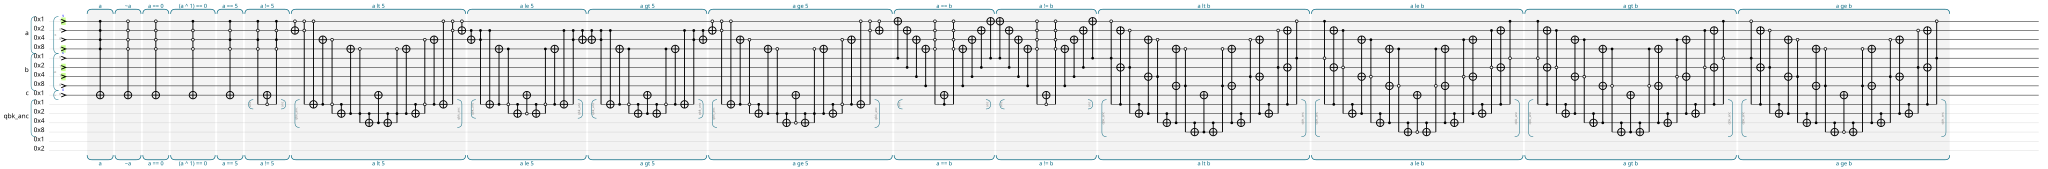

In [4]:
from psiqworkbench import QPU, Qubits


def run():
    qc = QPU()                           # Create a QPU
    qc.reset(15)                         # Initialize it with some qubits
    a = Qubits(4, 'a', qc)               # Allocate a register to test on
    b = Qubits(4, 'b', qc)               # Allocate a register to test on
    c = Qubits(1, 'c', qc)               # Allocate a register to test on
    
    a.write(9)                           # Set some initial values
    b.write(6)                           # Set some initial values
    c.write(0)                           # Set some initial values

    qc.nop()


    qc.nop()

    qc.label('a')
    qc.nop()
    c.x(a)                             # Apply op to any terms where a is all 1
    qc.nop()

    qc.label('~a')
    qc.nop()
    c.x(~a)                            # Apply op to any terms where a is all 0
    qc.nop()

    qc.label('a == 0')
    qc.nop()
    c.x(a == 0)                       # Tell the QPU to only apply these if a is non-zero
    qc.nop()

    qc.label('(a ^ 1) == 0')
    qc.nop()
    c.x((a ^ 1) == 0)                       # Tell the QPU to only apply these if a ^ 1 == 0
    qc.nop()

    qc.label('a == 5')
    qc.nop()
    c.x(a == 5)
    qc.nop()

    qc.label('a != 5')
    with a != 5 as cond:                       # Tell the QPU to only apply these if a != 5
        c.x(cond)

    qc.label('a lt 5')
    with a < 5 as cond:                        # Tell the QPU to only apply these if a < 5
        c.x(cond)

    qc.label('a le 5')
    with a <= 5 as cond:                       # Tell the QPU to only apply these if a <= 5
        c.x(cond)

    qc.label('a gt 5')
    with a > 5 as cond:                        # Tell the QPU to only apply these if a > 5
        c.x(cond)

    qc.label('a ge 5')
    with a >= 5 as cond:                       # Tell the QPU to only apply these if a >= 5
        c.x(cond)

    qc.nop()

    qc.label('a == b')
    with a == b as cond:                      # Tell the QPU to only apply these if a == bb
        c.x(cond)

    qc.label('a != b')
    with a != b as cond:                      # Tell the QPU to only apply these if a != bb
        c.x(cond)

    qc.label('a lt b')
    with a < b as cond:                       # Tell the QPU to only apply these if a < bb
        c.x(cond)

    qc.label('a le b')
    with a <= b as cond:                      # Tell the QPU to only apply these if a <= bb
        c.x(cond)

    qc.label('a gt b')
    with a > b as cond:                       # Tell the QPU to only apply these if a > bb
        c.x(cond)

    qc.label('a ge b')
    with a >= b as cond:                      # Tell the QPU to only apply these if a >= bb
        c.x(cond)


    qc.label('')
    for i in range(10):                   # Just space things out a bit to look nice
        qc.nop()
    qc.draw()                            # Draw the whole circuit
    
run()